In [1]:
import torch
from torch import nn
from matplotlib import pyplot as plt
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

In [2]:
train_data = datasets.CIFAR10(
    root = "data",
    train = True,
    transform = ToTensor(),
    target_transform = None,
    download = True
)

test_data = datasets.CIFAR10(
    root = "data",
    train = False,
    transform = ToTensor(),
    target_transform = None,
    download = True
)

Files already downloaded and verified
Files already downloaded and verified


In [3]:
type(train_data)

torchvision.datasets.cifar.CIFAR10

In [4]:
train_data[0]

(tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
          [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
          [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
          ...,
          [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
          [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
          [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],
 
         [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
          [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
          [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
          ...,
          [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
          [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
          [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],
 
         [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
          [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
          [0.0824, 0.0000, 0.0314,  ...,

In [5]:
type(train_data[0])

tuple

In [6]:
image, label = train_data[0]

In [7]:
image

tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
         [0.0824, 0.0000, 0.0314,  ..., 0.1961, 0.1961, 0.

In [8]:
label

6

In [9]:
image.shape

torch.Size([3, 32, 32])

color channels = 3 (RGB)

32 = height, 32 = width

In [10]:
len(train_data), len(test_data)

(50000, 10000)

In [11]:
class_names = train_data.classes

In [12]:
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

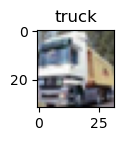

In [13]:
image, label = train_data[1]
image = image.permute(1,2,0)   #Bu şekilde yapmazsak yani örneğin (32, 32, 3) olacak ayara getirmezsek imshow hata veriyor
plt.figure(figsize = (1,1))
plt.imshow(image)
plt.title(class_names[label])
plt.show()

CIFAR10 dataset’i 50.000 eğitim görüntüsünden oluşur. Her görüntü: 3 kanal (R, G, B) ve boyut 32×32.

Bu sayılar, CIFAR10 dataset’inin tüm eğitim seti üzerinde hesaplanmış istatistiklerdir.

Yani: 
- mean (RGB): [0.491, 0.482, 0.446] → CIFAR10 görüntülerinin kırmızı, yeşil ve mavi kanallarının ortalaması. • std (RGB): [0.247, 0.243, 0.261] → Aynı kanalların standart sapması.

CNN’ler, özellikle Adam ve SGD gibi optimizasyon algoritmaları, standartlaştırılmış girişlerle çok daha iyi öğrenir.

Normalize edilmemiş görüntü: 
- Piksel değerleri 0–255 arasında düzensiz dağılmış
- Kanal başına farklı ortalamalar
- Modelin ilk katmanı için öğrenme zorlaşır

Normalize edilmiş görüntü: 
- Tüm görüntünün ortalaması ~ 0
- Dağılımın genişliği ~ 1
- Tüm kanallar daha benzer ölçeğe sahip

Bu:
- Modelin hızlı öğrenmesini sağlar
- daha stabil loss • Gradientlerin daha “dengeli” akması
- Yüksek learning rate’lerin çalışabilmesi
- Genel accuracy’nin ciddi şekilde artması

In [14]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.491, 0.482, 0.446],
                         std=[0.247, 0.243, 0.261])
])

In [15]:
train_data = datasets.CIFAR10(
    root = "data",
    train = True,
    transform = transform,
    target_transform = None,
    download = True
)

test_data = datasets.CIFAR10(
    root = "data",
    train = False,
    transform = transform,
    target_transform = None,
    download = True
)

Files already downloaded and verified
Files already downloaded and verified


In [16]:
image, label = train_data[1]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9084703..2.10758].


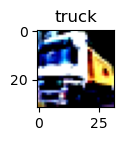

In [17]:
image = image.permute(1,2,0)
plt.figure(figsize = (1, 1))
plt.imshow(image)
plt.title(class_names[label])
plt.show()

In [18]:
from torch.utils.data import DataLoader

In [19]:
BATCH_SIZE = 32

train_dataloader = DataLoader(
    dataset = train_data,
    batch_size = 32,
    shuffle = True
)

test_dataloader = DataLoader(
    dataset = test_data,
    batch_size = 32,
    shuffle = False
)

In [20]:
print(f"Train Data Loader Size: {len(train_dataloader)}")
print(f"Test Data Loader Size: {len(test_dataloader)}")

Train Data Loader Size: 1563
Test Data Loader Size: 313


In [21]:
1563 * 32 , 313 * 32

(50016, 10016)

In [22]:
train_dataloader.dataset[0][0].shape

torch.Size([3, 32, 32])

### Flatten Layer

Flatten (Düzleştirme) katmanı, yapay zeka modellerinde (özellikle Evrişimli Sinir Ağlarında - CNN) çok boyutlu matrisleri tek boyutlu bir dizi (vektör) haline getiren bir köprü katmanıdır.

Kendi başına herhangi bir matematiksel ağırlık (weight) veya bias içermez; yani eğitim sırasında öğrenilen bir katman değildir. Tek işlevi verinin şeklini (shape) değiştirmektir.

CNN modellerinde görsel işlenirken veriler 3 boyutlu matrisler (Yükseklik, Genişlik, Kanal/Filtre sayısı) halindedir. Ancak modelin en sonunda, görselin ne olduğunu tahmin eden (kedi, köpek, araba vb.) klasik Fully Connected (Tam Bağlantılı / Doğrusal) katmanlar bulunur.

Sorun: Tam bağlantılı katmanlar (nn.Linear), girdileri yalnızca tek boyutlu (vektör) olarak kabul edebilir. 3 boyutlu bir matrisi doğrudan bu katmana bağlayamazsınız.

Çözüm: Flatten devreye girer. Matristeki tüm pikselleri ve özellikleri uç uca ekleyerek uzun, tek boyutlu bir çizgi haline getirir.

In [23]:
# Örnek Senaryo

flatten_model = nn.Flatten()

first_data = train_dataloader.dataset[0][0]
flattened_data = flatten_model(first_data)

print(f"Shape before flattening: {first_data.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {flattened_data.shape} -> [color_channels, height*width]")

Shape before flattening: torch.Size([3, 32, 32]) -> [color_channels, height, width]
Shape after flattening: torch.Size([3, 1024]) -> [color_channels, height*width]


In [24]:
class CIFAR10Classifier(nn.Module):

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = input_shape, out_features = hidden_units),
            nn.Linear(in_features = hidden_units, out_features = output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)

In [25]:
first_data.shape

torch.Size([3, 32, 32])

In [26]:
3 * 32 * 32

3072

In [27]:
len(class_names)

10

In [28]:
torch.manual_seed(42)

model_0 = CIFAR10Classifier(
    input_shape = 3072,
    hidden_units = 32,
    output_shape = len(class_names)
)

In [29]:
model_0

CIFAR10Classifier(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=32, bias=True)
    (2): Linear(in_features=32, out_features=10, bias=True)
  )
)

In [30]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params = model_0.parameters(),
    lr = 0.01
)

In [31]:
def calculate_accuracy(y_pred, y_true):
    correct = torch.eq(y_pred, y_true).sum().item()
    acc = (correct / len(y_true)) * 100

    return acc

In [32]:
torch.manual_seed(42)

epochs = 10

for epoch in range(epochs):

    # Training Step
    train_loss = 0

    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()

        y_pred = model_0(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 500 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")


    # Testing Step
    test_loss = 0
    test_acc = 0

    model_0.eval()
    with torch.inference_mode():
        for X,y in test_dataloader:
            
            test_pred = model_0(X)

            test_loss += loss_fn(test_pred, y)
            test_acc += calculate_accuracy(y, test_pred.argmax(dim=1))
            
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 3869.21094 | Test loss: 2.69594, Test acc: 27.54%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 3950.02881 | Test loss: 2.44923, Test acc: 28.00%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 3911.81836 | Test loss: 2.60526, Test acc: 27.92%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 3965.25195 | Test loss: 2.62773, Test acc: 27.15%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 3924.77173 | Test loss: 2.48330, Test acc: 25.74%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 4800

In [33]:
def evaluate_model_performance(model: nn.Module, 
                               data_loader: torch.utils.data.DataLoader,
                               loss_fn: torch.nn.Module,
                               accuracy_function):
    loss = 0
    acc = 0
    model.eval()
    with torch.inference_mode():
        for X,y in data_loader:
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_function(y, y_pred.argmax(dim = 1))

        loss /= len(data_loader)
        acc /= len(data_loader)

    return {
        "model_name" : model.__class__.__name__,
        "model_loss" : loss.item(),
        "model_accuracy" : acc
    }

In [34]:
model_0_results = evaluate_model_performance(model = model_0, data_loader = test_dataloader, loss_fn = loss_fn, accuracy_function = calculate_accuracy)

In [35]:
model_0_results

{'model_name': 'CIFAR10Classifier',
 'model_loss': 2.721501350402832,
 'model_accuracy': 23.961661341853034}

Lineer olarak yazdığımız modeli test datası üzerinden test ettik. Şimdi de buna non-lineer katmanlar ekleyerek test edelim.

In [36]:
class CIFAR10ClassifierNonLinear(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = input_shape, out_features = hidden_units),
            nn.ReLU(),
            nn.Linear(in_features = hidden_units, out_features = output_shape)
        )

    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)

In [37]:
torch.manual_seed(42)
model_1 = CIFAR10ClassifierNonLinear(
    input_shape = 3072,
    hidden_units = 32,
    output_shape = len(class_names)
)

In [38]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_1.parameters(), lr = 0.01)

In [39]:
torch.manual_seed(42)

epochs = 10

for i in range(epochs):
    train_loss = 0
    for batch, (X, y) in enumerate(train_dataloader):
        model_1.train()

        y_pred = model_1(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(train_dataloader)


    test_loss , test_acc = 0, 0
    model_1.eval()
    with torch.inference_mode():
        for X,y in test_dataloader:
            test_pred = model_1(X)

            test_loss += loss_fn(test_pred, y)
            test_acc += calculate_accuracy(y_true = y, y_pred = test_pred.argmax(dim = 1))

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(f" Train Loss: {train_loss:.5f} | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.5f}\n")

Epoch: 9.0000 | Train Loss: 2.34137 | Test Loss: 2.42599 | Test Accuracy: 28.82388

Epoch: 9.0000 | Train Loss: 2.30196 | Test Loss: 2.61636 | Test Accuracy: 28.23482

Epoch: 9.0000 | Train Loss: 2.22570 | Test Loss: 2.24907 | Test Accuracy: 27.85543

Epoch: 9.0000 | Train Loss: 2.21300 | Test Loss: 2.11343 | Test Accuracy: 30.18171

Epoch: 9.0000 | Train Loss: 2.18527 | Test Loss: 2.27650 | Test Accuracy: 28.61422

Epoch: 9.0000 | Train Loss: 2.14660 | Test Loss: 2.26678 | Test Accuracy: 30.89058

Epoch: 9.0000 | Train Loss: 2.12824 | Test Loss: 2.14431 | Test Accuracy: 30.64097

Epoch: 9.0000 | Train Loss: 2.13708 | Test Loss: 2.25766 | Test Accuracy: 27.14657

Epoch: 9.0000 | Train Loss: 2.10129 | Test Loss: 2.41017 | Test Accuracy: 28.68411

Epoch: 9.0000 | Train Loss: 2.09786 | Test Loss: 2.18715 | Test Accuracy: 28.24481



In [40]:
model_1_results = evaluate_model_performance(model_1, test_dataloader, loss_fn, calculate_accuracy)

In [41]:
model_1_results

{'model_name': 'CIFAR10ClassifierNonLinear',
 'model_loss': 2.1871466636657715,
 'model_accuracy': 28.244808306709267}

Aşağıdaki sınıfı Tiny VGG modelinin paperindaki kurulmuş sinir ağına göre hazırladık. Bütün parametreler vs. makaleden alındı.

In [42]:
class CIFAR10ClassifierCNN(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels = input_shape, out_channels = hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units, out_channels = hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride =2)
        )

        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels = hidden_units, out_channels = hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units, out_channels = hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride =2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = hidden_units * 8 * 8, out_features = len(class_names))
        )

    def forward(self, x):
        return self.classifier(self.block_2(self.block_1(x)))

En son katmandaki Lineer'de in featuresi hesaplamak için aşağıdaki yöntemi izledik.

In [45]:
x = torch.rand(1, 3, 32, 32)   # Bizim verimizdeki boyutlar 32x32. Ayrıca 3 channel var. 1 batchlil gibi düşündüğümüzden ilk seçenek 1 oldu.
print("Input: [batch, channels, height, width]", x.shape)

# 1.Blok
conv1 = nn.Conv2d(3, 10, kernel_size=3, stride = 1, padding = 1)
conv2 = nn.Conv2d(10, 10, kernel_size=3, stride = 1, padding = 1)
pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)

x = conv1(x)
print("After Conv1 : ", x.shape)

x = conv2(x)
print("After Conv2 : ", x.shape)

x = pool1(x)
print("After MaxPool1 : ", x.shape)


# 2.Blok
conv3 = nn.Conv2d(10, 10, kernel_size=3, stride = 1, padding = 1)
conv4 = nn.Conv2d(10, 10, kernel_size=3, stride = 1, padding = 1)
pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2)

x = conv3(x)
print("After Conv3 : ", x.shape)

x = conv4(x)
print("After Conv4 : ", x.shape)

x = pool2(x)
print("After MaxPool2 : ", x.shape)

Input: [batch, channels, height, width] torch.Size([1, 3, 32, 32])
After Conv1 :  torch.Size([1, 10, 32, 32])
After Conv2 :  torch.Size([1, 10, 32, 32])
After MaxPool1 :  torch.Size([1, 10, 16, 16])
After Conv3 :  torch.Size([1, 10, 16, 16])
After Conv4 :  torch.Size([1, 10, 16, 16])
After MaxPool2 :  torch.Size([1, 10, 8, 8])


In [47]:
model_2 = CIFAR10ClassifierCNN(input_shape = 3, # 3 renk kanalı
                               hidden_units = 32,
                               output_shape = len(class_names))

In [48]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_2.parameters(), lr = 0.001)

In [49]:
epochs = 10

for epoch in range(epochs):
    # Training Step
    train_loss = 0

    for batch, (X, y) in enumerate(train_dataloader):
        model_2.train()

        y_pred = model_2(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if batch % 500 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    train_loss /= len(train_dataloader)
    
    
    # Testing Step
    test_loss, test_acc = 0, 0
    model_2.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            test_pred = model_2(X)

            test_loss += loss_fn(test_pred, y)
            test_acc += calculate_accuracy(y, test_pred.argmax(dim = 1))

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 1.34614 | Test loss: 1.03199, Test acc: 64.09%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 0.93340 | Test loss: 0.90707, Test acc: 68.41%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 0.79580 | Test loss: 0.82270, Test acc: 71.50%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 0.71327 | Test loss: 0.80412, Test acc: 72.60%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 0.65221 | Test loss: 0.78999, Test acc: 73.31%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

In [50]:
print(evaluate_model_performance(model_0, test_dataloader, loss_fn, calculate_accuracy))

{'model_name': 'CIFAR10Classifier', 'model_loss': 2.721501350402832, 'model_accuracy': 23.961661341853034}


In [51]:
print(evaluate_model_performance(model_1, test_dataloader, loss_fn, calculate_accuracy))

{'model_name': 'CIFAR10ClassifierNonLinear', 'model_loss': 2.1871466636657715, 'model_accuracy': 28.244808306709267}


In [53]:
print(evaluate_model_performance(model_2, test_dataloader, loss_fn, calculate_accuracy))

{'model_name': 'CIFAR10ClassifierCNN', 'model_loss': 0.8478831052780151, 'model_accuracy': 73.3226837060703}


- model_0 = Lineer Model
- model_1 = Non Lineer Model
- model_2 = CNN Model

In [54]:
def make_predictions(model: torch.nn.Module, data: list):
    """
    data: [img_tensor, img_tensor, ...]  # her biri [C, H, W]
    return: [N, num_classes] olasılık tensörü
    """
    pred_probs = []
    model.eval()

    with torch.inference_mode():
        for sample in data:
            # [C, H, W] -> [1, C, H, W]
            sample = sample.unsqueeze(0)

            # Logits al
            pred_logit = model(sample)    # shape: [1, num_classes]

            # Softmax ile olasılığa çevir
            prob = torch.softmax(pred_logit, dim=1)  # [1, num_classes]

            # Batch boyutunu sıkıştır
            pred_probs.append(prob.squeeze(0))       # [num_classes]

    # Hepsini birleştir → [N, num_classes]
    return torch.stack(pred_probs)

In [55]:
import random
def show_random_predictions(model, dataset, class_names, n=9):
    model.eval()
    
    plt.figure(figsize=(4, 4))

    # random 9 index seç
    indices = random.sample(range(len(dataset)), n)

    with torch.inference_mode():
        for i, idx in enumerate(indices):
            img, true_label = dataset[idx]

            # modele uygun hale getir
            img_input = img.unsqueeze(0)  
            logits = model(img_input)
            pred_label = logits.argmax(dim=1).item()

            # görseli çizmek için permute
            img_show = img.permute(1, 2, 0)

            # doğru mu yanlış mı?
            correct = (pred_label == true_label)
            color = "green" if correct else "red"

            # subplot
            plt.subplot(3, 3, i + 1)
            plt.imshow(img_show)
            plt.axis("off")

            plt.title(
                f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}",
                color=color,
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8705721..1.6152667].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9835391..2.0474794].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9878542..2.1316872].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7655791..1.9541677].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9878542..1.8573389].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9512628..2.044852].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7497023

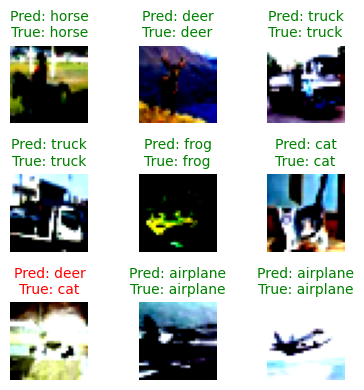

In [57]:
show_random_predictions(model_2, test_data, class_names)